In [13]:
pip install scikit-optimize


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.6 MB/s eta 0:00:00


In [14]:
from skopt import gp_minimize
from skopt.space import Real
import numpy as np
import pandas as pd

amin_1DE_R = np.load('/content/R_DE1_amin.npy')
amin_2DE_R = np.load('/content/R_DE2_amin.npy')
df = pd.read_csv('/content/output.csv')
categories = df['category'].str.strip().str.lower().values[:600]

def objective(params):
    threshold, mu0, non_decision_time = params
    time_step_ms = 5
    n_stimuli = amin_1DE_R.shape[0]

    correct_count = 0
    total_valid = 0

    for i in range(n_stimuli):
        r1 = amin_1DE_R[i]
        r2 = amin_2DE_R[i]

        start_index = int(non_decision_time // time_step_ms)

        r1 = r1[start_index:]
        r2 = r2[start_index:]

        above_thresh_1 = np.where(r1 >= threshold)[0]
        above_thresh_2 = np.where(r2 >= threshold)[0]

        t1 = above_thresh_1[0] if len(above_thresh_1) > 0 else np.inf
        t2 = above_thresh_2[0] if len(above_thresh_2) > 0 else np.inf

        if t1 == np.inf and t2 == np.inf:
            continue

        decision = 'animal' if t1 < t2 else 'non-animal'

        if categories[i] == decision:
            correct_count += 1
        total_valid += 1

    accuracy = correct_count / total_valid if total_valid > 0 else 0
    return -accuracy
res = gp_minimize(
    func=objective,
    dimensions=[
        Real(10, np.max([amin_1DE_R.max(), amin_2DE_R.max()]), name='threshold'),
        Real(50, 80, name='mu0'),
        Real(0, 300, name='non_decision_time')
    ],
    n_calls=30,
    random_state=42
)

print("✅ Best Parameters:")
print(f"Threshold: {res.x[0]:.2f}")
print(f"Mu0: {res.x[1]:.2f}")
print(f"Non-decision time: {res.x[2]:.2f} ms")
print(f"Best Accuracy: {-res.fun:.4f}")


✅ Best Parameters:
Threshold: 63.10
Mu0: 55.50
Non-decision time: 233.91 ms
Best Accuracy: 1.0000


In [17]:
import re
from collections import defaultdict
import numpy as np
def categorize_file(filename):
    match = re.search(r'([A-Z]{1,3})_', filename)
    if not match:
        match = re.search(r'([A-Z][a-z][a-z]{1,3})_', filename)
    if not match:

        return filename, 'Unknown', 'Unknown'

    prefix = match.group(1)

    if prefix in animal_prefixes:
        category = 'Animal'
    elif prefix in non_animal_prefixes:
        category = 'Non-Animal'
    else:
        category = 'Unknown'

    if prefix in distance_map:
        distance = distance_map[prefix]
    else:
        distance = distance_map.get(prefix[0], 'Unknown')
    return filename, category, distance


with open('y_amin_sorted.npy', 'r', encoding='utf-8') as f:
    data = f.read()


filenames = re.findall(r'[A-Za-z0-9_]+\.jpg', data)

animal_prefixes = ['F', 'H', 'M', 'B']
non_animal_prefixes = ['Fda', 'Fdn', 'Bda','Bdn','Hda','Hdn','Mda','Mdn']
distance_map = {
    'B': 'close body',
    'H': 'head',
    'F': 'far body',
    'M': 'medium body',
    'Bda': 'close body',
    'Hda': 'head',
    'Fda': 'far body',
    'Mda': 'medium body',
    'Bdn': 'close body',
    'Hdn': 'head',
    'Fdn': 'far body',
    'Mdn': 'medium body'
}
results=[]

for fname in filenames:
  results.append(categorize_file(fname))
print(results)

import pandas as pd


df = pd.DataFrame(results, columns=['file', 'category', 'distance'])


df.to_csv('output.csv', index=False, encoding='utf-8-sig')


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x93 in position 0: invalid start byte

In [18]:
import numpy as np

amin_1DE_R = np.load('/content/R_DE1_amin.npy')
amin_2DE_R = np.load('/content/R_DE2_amin.npy')

threshold = 63.10
non_decision_time = 233.91
time_step_ms = 5
n_stimuli = amin_1DE_R.shape[0]


decisions = []
reaction_times = []
confidences = []

for i in range(n_stimuli):
    r1 = amin_1DE_R[i]
    r2 = amin_2DE_R[i]
    threshold = 0.2 * max(max(r1), max(r2))

    above_thresh_1DE = np.where(r1 >= threshold)[0]
    above_thresh_2DE = np.where(r2 >= threshold)[0]

    if len(above_thresh_1DE) == 0 and len(above_thresh_2DE) == 0:
        decisions.append('NoDecision')
        reaction_times.append(None)
        confidences.append(None)
        continue

    t1 = above_thresh_1DE[0] if len(above_thresh_1DE) > 0 else np.inf
    t2 = above_thresh_2DE[0] if len(above_thresh_2DE) > 0 else np.inf

    if t1 < t2:
        decisions.append('Animal')
    elif t2 < t1:
        decisions.append('Non-Animal')
    else:
        decisions.append('Tie')


    threshold = 0.8 * max(max(r1), max(r2))
    above_thresh_1DE = np.where(r1 >= threshold)[0]
    above_thresh_2DE = np.where(r2 >= threshold)[0]
    t1 = above_thresh_1DE[0] if len(above_thresh_1DE) > 0 else np.inf
    t2 = above_thresh_2DE[0] if len(above_thresh_2DE) > 0 else np.inf

    if t1 < t2:
        decision_time_index = t1
    elif t2 < t1:
        decision_time_index = t2
    else:
        decision_time_index = t1

    reaction_time_ms = decision_time_index * time_step_ms + non_decision_time
    reaction_times.append(reaction_time_ms)


    window = 50
    end_index = min(decision_time_index + window, len(r1))

    mean_r1 = r1[decision_time_index:end_index].mean()
    mean_r2 = r2[decision_time_index:end_index].mean()

    confidence = abs(mean_r1 - mean_r2) / (mean_r1 + mean_r2) * 100
    confidences.append(confidence)

import pandas as pd

df = pd.read_csv('/content/output.csv')


df_subset = df.iloc[:len(decisions)].copy()

df_subset['response'] = decisions
df_subset['reaction_time'] = reaction_times
df_subset['confidence'] = confidences

df_subset.to_csv('/content/data_with_decision.csv', index=False)


df = pd.read_csv('/content/data_with_decision.csv')
df['category'] = df['category'].str.strip().str.lower()
df['response'] = df['response'].str.strip().str.lower()

df['response'] = df['response'].replace({'animall': 'animal', 'nonanimall': 'non-animal'})

df['correct'] = (df['category'] == df['response']).astype(int)

df.to_csv('/content/data_with_decision_and_correct.csv', index=False)



In [ ]:
print("🔍 Max firing rate in 1DE:", np.max(amin_1DE_R))
print("🔍 Max firing rate in 2DE:", np.max(amin_2DE_R))


🔍 Max firing rate in 1DE: 76.66666666666666
🔍 Max firing rate in 2DE: 71.66666666666667


category
animal       300
nonanimal    300
Name: count, dtype: int64


/tmp/ipython-input-3374177239.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_by_distance = df.groupby('distance')['correct'].mean()


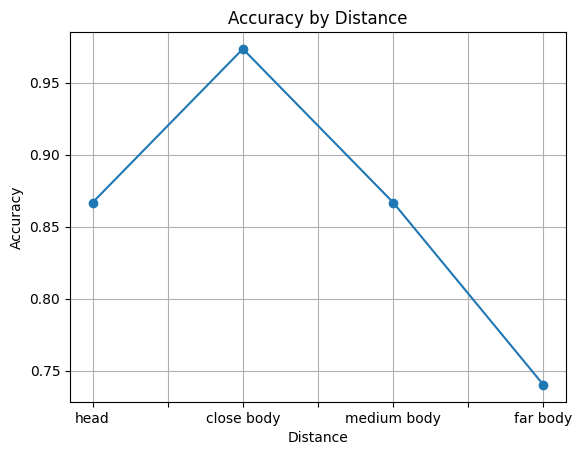

/tmp/ipython-input-3374177239.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_by_distance = df.groupby('distance')['reaction_time'].mean()


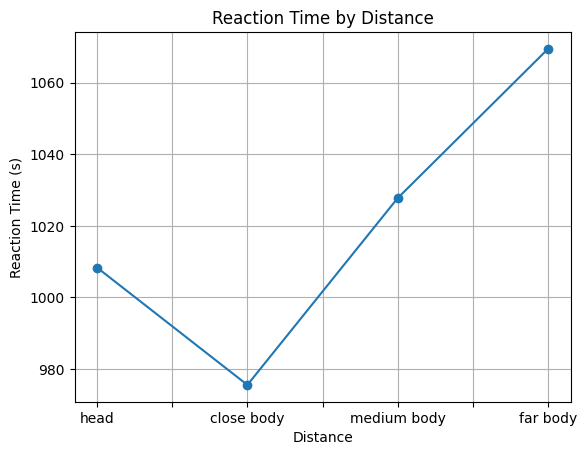

/tmp/ipython-input-3374177239.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_by_distance = df.groupby('distance')['confidence'].mean()


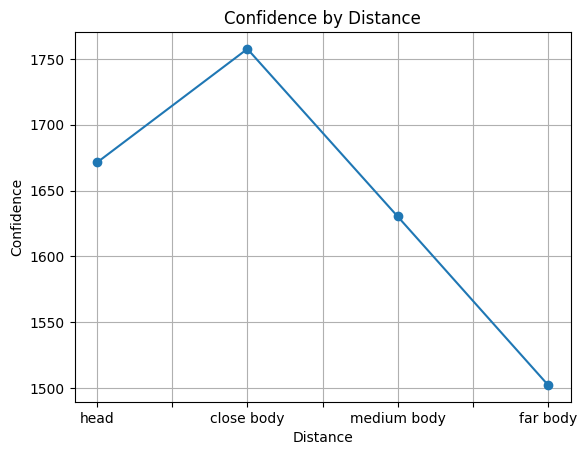

/tmp/ipython-input-3374177239.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_by_category = df.groupby('category')['correct'].mean()
/tmp/ipython-input-3374177239.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_by_category = df.groupby('category')['reaction_time'].mean()
/tmp/ipython-input-3374177239.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_by_category = df.groupby('category')['conf

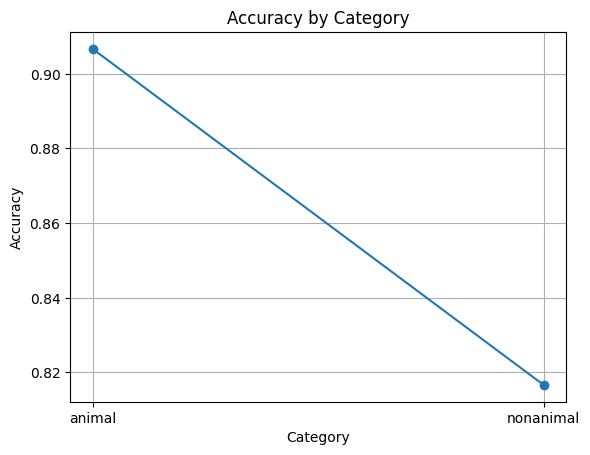

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

files = ['/content/data_with_decision_and_correct.csv']

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

def clean_category(x):
    x = x.strip().lower()
    if x == 'animal':
        return 'animal'
    elif x == 'non-animal':
        return 'nonanimal'
    else:
        return x

df['category'] = df['category'].apply(clean_category)
print(df['category'].value_counts())
df['correct'] = df['correct'].astype(int)
distance_order = ['head','close body', 'medium body', 'far body']
df['distance'] = pd.Categorical(df['distance'], categories=distance_order, ordered=True)



accuracy_by_distance = df.groupby('distance')['correct'].mean()
plt.figure()
accuracy_by_distance.plot(marker='o')
plt.title('Accuracy by Distance')
plt.ylabel('Accuracy')
plt.xlabel('Distance')
plt.grid(True)
plt.savefig('accuracy_by_distance.png')
plt.show()


rt_by_distance = df.groupby('distance')['reaction_time'].mean()
plt.figure()
rt_by_distance.plot(marker='o')
plt.title('Reaction Time by Distance')
plt.ylabel('Reaction Time (s)')
plt.xlabel('Distance')
plt.grid(True)
plt.savefig('reactiontime_by_distance.png')
plt.show()


conf_by_distance = df.groupby('distance')['confidence'].mean()
conf_by_distance = conf_by_distance * 20
plt.figure()
conf_by_distance.plot(marker='o')
plt.title('Confidence by Distance')
plt.ylabel('Confidence')
plt.xlabel('Distance')
plt.grid(True)
plt.savefig('confidence_by_distance.png')
plt.show()

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt


df['category'] = pd.Categorical(df['category'], categories=['animal', 'nonanimal'], ordered=True)
accuracy_by_category = df.groupby('category')['correct'].mean()
rt_by_category = df.groupby('category')['reaction_time'].mean()
conf_by_category = df.groupby('category')['confidence'].mean()

categories = accuracy_by_category.index.tolist()


plt.figure()
plt.plot(categories, accuracy_by_category.values, marker='o')
plt.title('Accuracy by Category')
plt.xlabel('Category')
plt.ylabel('Accuracy')
plt.grid(True)
plt.savefig('accuracy_by_category.png')
plt.show()




/tmp/ipython-input-1661786150.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_correct = df[df['correct'] == 1].groupby('category')['reaction_time'].agg(['mean', 'sem'])
/tmp/ipython-input-1661786150.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_incorrect = df[df['correct'] == 0].groupby('category')['reaction_time'].agg(['mean', 'sem'])


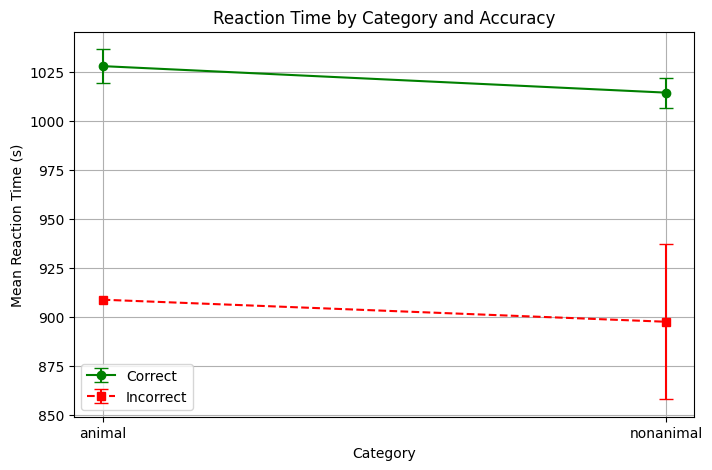

/tmp/ipython-input-1661786150.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_correct = df[df['correct'] == 1].groupby('category')['confidence'].agg(['mean', 'sem'])
/tmp/ipython-input-1661786150.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_incorrect = df[df['correct'] == 0].groupby('category')['confidence'].agg(['mean', 'sem'])


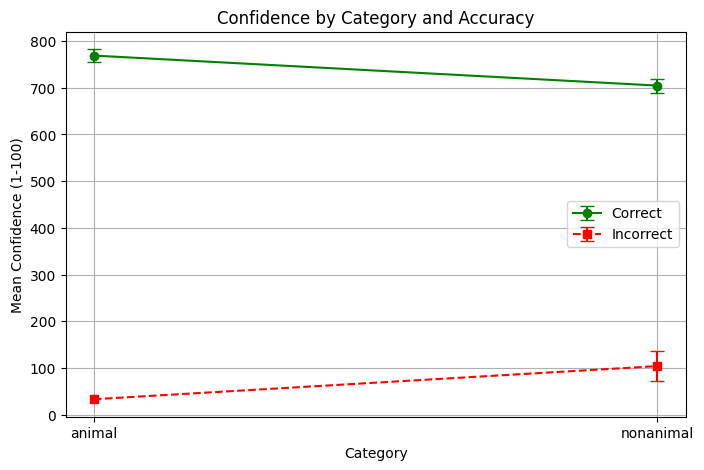

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df['category'] = pd.Categorical(df['category'], categories=['animal', 'nonanimal'], ordered=True)

categories = ['animal', 'nonanimal']

rt_correct = df[df['correct'] == 1].groupby('category')['reaction_time'].agg(['mean', 'sem'])
rt_incorrect = df[df['correct'] == 0].groupby('category')['reaction_time'].agg(['mean', 'sem'])

plt.figure(figsize=(8,5))
plt.errorbar(categories, rt_correct.loc[categories, 'mean'], yerr=rt_correct.loc[categories, 'sem'],
             fmt='o-', capsize=5, label='Correct', color='green')
plt.errorbar(categories, rt_incorrect.loc[categories, 'mean'], yerr=rt_incorrect.loc[categories, 'sem'],
             fmt='s--', capsize=5, label='Incorrect', color='red')

plt.title('Reaction Time by Category and Accuracy')
plt.xlabel('Category')
plt.ylabel('Mean Reaction Time (s)')
plt.grid(True)
plt.legend()
plt.savefig('reactiontime_by_category.png')
plt.show()

df['category'] = pd.Categorical(df['category'], categories=['animal', 'nonanimal'], ordered=True)

conf_correct = df[df['correct'] == 1].groupby('category')['confidence'].agg(['mean', 'sem'])
conf_incorrect = df[df['correct'] == 0].groupby('category')['confidence'].agg(['mean', 'sem'])

categories = conf_correct.index.tolist()

conf_correct['mean'] *= 20
conf_correct['sem'] *= 20
conf_incorrect['mean'] *= 20
conf_incorrect['sem'] *= 20

plt.figure(figsize=(8,5))

plt.errorbar(categories, conf_correct['mean'], yerr=conf_correct['sem'], fmt='o-', capsize=5, label='Correct', color='green')
plt.errorbar(categories, conf_incorrect['mean'], yerr=conf_incorrect['sem'], fmt='s--', capsize=5, label='Incorrect', color='red')

plt.title('Confidence by Category and Accuracy')
plt.xlabel('Category')
plt.ylabel('Mean Confidence (1-100)')
plt.grid(True)
plt.legend()
plt.savefig('confidence_by_category.png')
plt.show()


